In [120]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [121]:
df = pd.DataFrame()

In [122]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['y']  = [1,1,0,1,0,1,0,1,0,0]
df

,X1,X2,y
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

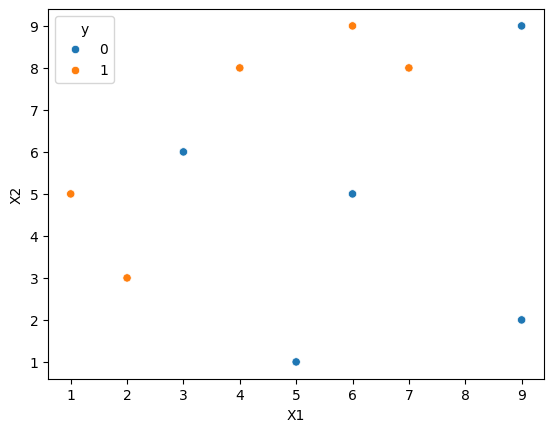

In [123]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'], hue=df['y'])

In [124]:
df['W'] = 1/df.shape[0]

In [125]:
df

,X1,X2,y,W
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


### AdaBoost

In [126]:
from sklearn.tree import DecisionTreeClassifier

In [127]:
dt1 = DecisionTreeClassifier(max_depth=1) # Decision Stump

In [128]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [129]:
dt1.fit(X, y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

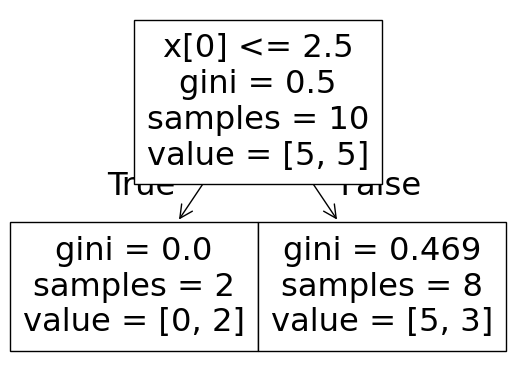

In [130]:
from sklearn.tree import plot_tree

plot_tree(dt1) # Decision Stump

<Axes: >

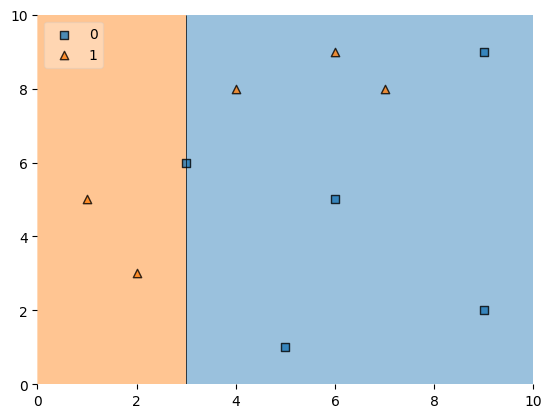

In [131]:
plot_decision_regions(X, y, clf=dt1, legend=2)

In [132]:
df['y_pred'] = dt1.predict(X)

In [133]:
df  # we got 3 misclassifications

,X1,X2,y,W,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [134]:
error = lambda df: sum(df['W']*(df['y'] != df['y_pred']))

In [135]:
def calc_weight(err):
  return 0.5*np.log((1-err)/(err+0.0000000001))   # handle divide by zero if error got zero

In [136]:
err = error(df)

alpha1 = calc_weight(err)

alpha1, err

(np.float64(0.42364893002693504), 0.30000000000000004)

In [137]:
def update_row_weights(row,alpha=alpha1):
  if row['y'] == row['y_pred']:
    return row['W']*np.exp(-alpha)
  else:
    return row['W'] * np.exp(alpha)

In [138]:
df['updated_weights'] = df.apply(update_row_weights, axis=1)

In [139]:
df

,X1,X2,y,W,y_pred,updated_weights
0,1,5,1,0.1,1,0.065465
1,2,3,1,0.1,1,0.065465
2,3,6,0,0.1,0,0.065465
3,4,8,1,0.1,0,0.152753
4,5,1,0,0.1,0,0.065465
5,6,9,1,0.1,0,0.152753
6,6,5,0,0.1,0,0.065465
7,7,8,1,0.1,0,0.152753
8,9,9,0,0.1,0,0.065465
9,9,2,0,0.1,0,0.065465


In [140]:
df['updated_weights'].sum()

np.float64(0.9165151389911681)

In [141]:
# the sum of updated weights should be equal to 1 so normalize them

In [142]:
df['Normalized_wt'] = df['updated_weights']/df['updated_weights'].sum()

In [143]:
df

,X1,X2,y,W,y_pred,updated_weights,Normalized_wt
0,1,5,1,0.1,1,0.065465,0.071429
1,2,3,1,0.1,1,0.065465,0.071429
2,3,6,0,0.1,0,0.065465,0.071429
3,4,8,1,0.1,0,0.152753,0.166667
4,5,1,0,0.1,0,0.065465,0.071429
5,6,9,1,0.1,0,0.152753,0.166667
6,6,5,0,0.1,0,0.065465,0.071429
7,7,8,1,0.1,0,0.152753,0.166667
8,9,9,0,0.1,0,0.065465,0.071429
9,9,2,0,0.1,0,0.065465,0.071429


In [144]:
df['Normalized_wt'].sum()

np.float64(1.0)

In [145]:
# Create Ranges, using cumulative sum
df['cumsum_upper'] = np.cumsum(df['Normalized_wt'])
df['cumsum_lower'] = df['cumsum_upper'] - df['Normalized_wt']

In [146]:
df[['X1', 'X2',	'y', 'W', 'y_pred','updated_weights','Normalized_wt','cumsum_lower', 'cumsum_upper']]

,X1,X2,y,W,y_pred,updated_weights,Normalized_wt,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065465,0.071429,0.000000,0.071429
1,2,3,1,0.1,1,0.065465,0.071429,0.071429,0.142857
2,3,6,0,0.1,0,0.065465,0.071429,0.142857,0.214286
3,4,8,1,0.1,0,0.152753,0.166667,0.214286,0.380952
4,5,1,0,0.1,0,0.065465,0.071429,0.380952,0.452381
5,6,9,1,0.1,0,0.152753,0.166667,0.452381,0.619048
6,6,5,0,0.1,0,0.065465,0.071429,0.619048,0.690476
7,7,8,1,0.1,0,0.152753,0.166667,0.690476,0.857143
8,9,9,0,0.1,0,0.065465,0.071429,0.857143,0.928571
9,9,2,0,0.1,0,0.065465,0.071429,0.928571,1.000000


In [147]:
# Now we need new Dataset to pass it to new model but the dataset will contain
# Random Samples from dataset 1

def create_new_dataset(df):
  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index, row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [148]:
index_values = create_new_dataset(df)

In [149]:
index_values

[9, 7, 2, 5, 1, 4, 3, 3, 3, 1]

In [150]:
second_df = df.iloc[index_values, [0,1,2,3]]
second_df

,X1,X2,y,W
9,9,2,0,0.1
7,7,8,1,0.1
2,3,6,0,0.1
5,6,9,1,0.1
1,2,3,1,0.1
4,5,1,0,0.1
3,4,8,1,0.1
3,4,8,1,0.1
3,4,8,1,0.1
1,2,3,1,0.1


In [151]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [152]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [153]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.219\nsamples = 8\nvalue = [1, 7]'),
 Text(0.625, 0.5, '  False')]

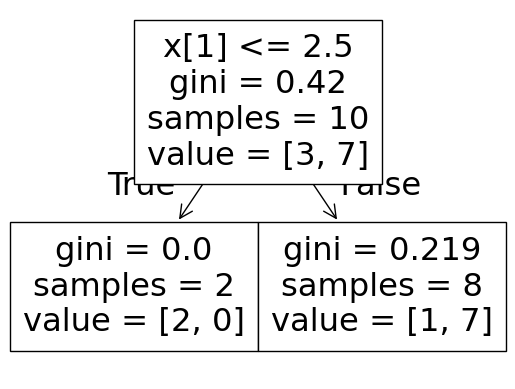

In [154]:
plot_tree(dt2)

<Axes: >

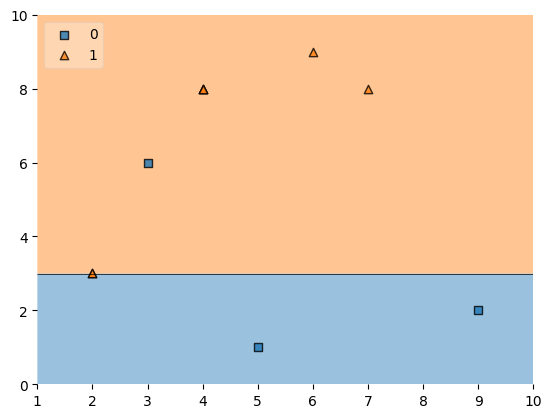

In [155]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [156]:
second_df['y_pred'] = dt2.predict(X)

In [157]:
second_df

,X1,X2,y,W,y_pred
9,9,2,0,0.1,0
7,7,8,1,0.1,1
2,3,6,0,0.1,1
5,6,9,1,0.1,1
1,2,3,1,0.1,1
4,5,1,0,0.1,0
3,4,8,1,0.1,1
3,4,8,1,0.1,1
3,4,8,1,0.1,1
1,2,3,1,0.1,1


In [158]:
error(second_df)  # zero error means all are correctly classified

0.1

In [159]:
err = error(second_df)

alpha2 = calc_weight(err)

alpha2, err

(np.float64(1.0986122881681097), 0.1)

In [160]:
second_df['updated_weights'] = second_df.apply(update_row_weights, axis=1)

In [161]:
second_df

,X1,X2,y,W,y_pred,updated_weights
9,9,2,0,0.1,0,0.065465
7,7,8,1,0.1,1,0.065465
2,3,6,0,0.1,1,0.152753
5,6,9,1,0.1,1,0.065465
1,2,3,1,0.1,1,0.065465
4,5,1,0,0.1,0,0.065465
3,4,8,1,0.1,1,0.065465
3,4,8,1,0.1,1,0.065465
3,4,8,1,0.1,1,0.065465
1,2,3,1,0.1,1,0.065465


In [162]:
second_df['Normalized_wt'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [163]:
second_df, second_df['Normalized_wt'].sum()

(   X1  X2  y    W  y_pred  updated_weights  Normalized_wt
 9   9   2  0  0.1       0         0.065465       0.088235
 7   7   8  1  0.1       1         0.065465       0.088235
 2   3   6  0  0.1       1         0.152753       0.205882
 5   6   9  1  0.1       1         0.065465       0.088235
 1   2   3  1  0.1       1         0.065465       0.088235
 4   5   1  0  0.1       0         0.065465       0.088235
 3   4   8  1  0.1       1         0.065465       0.088235
 3   4   8  1  0.1       1         0.065465       0.088235
 3   4   8  1  0.1       1         0.065465       0.088235
 1   2   3  1  0.1       1         0.065465       0.088235,
 np.float64(1.0))

In [164]:
# Create Ranges, using cumulative sum
second_df['cumsum_upper'] = np.cumsum(second_df['Normalized_wt'])
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['Normalized_wt']

In [166]:
second_df[['X1', 'X2',	'y', 'W', 'y_pred','updated_weights','Normalized_wt','cumsum_lower', 'cumsum_upper']]

,X1,X2,y,W,y_pred,updated_weights,Normalized_wt,cumsum_lower,cumsum_upper
9,9,2,0,0.1,0,0.065465,0.088235,0.000000,0.088235
7,7,8,1,0.1,1,0.065465,0.088235,0.088235,0.176471
2,3,6,0,0.1,1,0.152753,0.205882,0.176471,0.382353
5,6,9,1,0.1,1,0.065465,0.088235,0.382353,0.470588
1,2,3,1,0.1,1,0.065465,0.088235,0.470588,0.558824
4,5,1,0,0.1,0,0.065465,0.088235,0.558824,0.647059
3,4,8,1,0.1,1,0.065465,0.088235,0.647059,0.735294
3,4,8,1,0.1,1,0.065465,0.088235,0.735294,0.823529
3,4,8,1,0.1,1,0.065465,0.088235,0.823529,0.911765
1,2,3,1,0.1,1,0.065465,0.088235,0.911765,1.000000


In [167]:
index_values = create_new_dataset(second_df)

In [168]:
third_df = df.iloc[index_values, [0,1,2,3]]
third_df

,X1,X2,y,W
2,3,6,0,0.1
4,5,1,0,0.1
5,6,9,1,0.1
9,9,2,0,0.1
7,7,8,1,0.1
7,7,8,1,0.1
3,4,8,1,0.1
5,6,9,1,0.1
1,2,3,1,0.1
3,4,8,1,0.1


In [169]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

<Axes: >

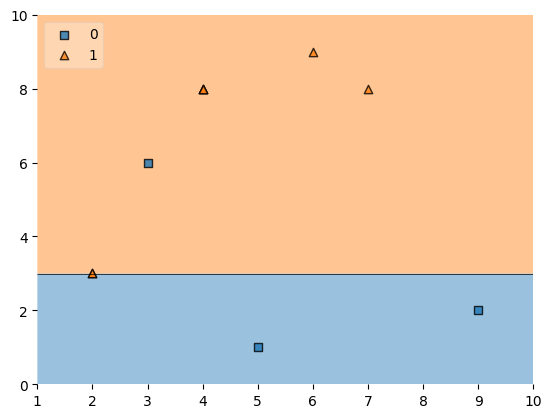

In [170]:
plot_decision_regions(X, y, clf=dt3, legend=2)

In [171]:
third_df['y_pred'] = dt3.predict(X)

third_df

,X1,X2,y,W,y_pred
2,3,6,0,0.1,0
4,5,1,0,0.1,1
5,6,9,1,0.1,1
9,9,2,0,0.1,1
7,7,8,1,0.1,1
7,7,8,1,0.1,0
3,4,8,1,0.1,1
5,6,9,1,0.1,1
1,2,3,1,0.1,1
3,4,8,1,0.1,1


In [183]:
err = error(third_df)

alpha3 = calc_weight(err)

alpha3, err

(np.float64(0.42364893002693504), 0.30000000000000004)

In [184]:
print(alpha1, alpha2, alpha3)

0.42364893002693504 1.0986122881681097 0.42364893002693504


### Prediction

In [267]:
query = np.array([9,5]).reshape(1,2)

In [268]:
p1 = dt1.predict(query)

In [269]:
p2 = dt2.predict(query)

In [270]:
p3 = dt3.predict(query)

In [271]:
H = alpha1*(1 if p1 == 1 else -1) + alpha2*(1 if p2 == 1 else -1) + alpha3*(1 if p3 == 1 else -1)    # 1 -> 1 and 0 -> -1

In [272]:
print("P1 : ", p1)
print("P2 : ", p2)
print("P3 : ", p3)
print("H : ", np.sign(H))

P1 :  [0]
P2 :  [1]
P3 :  [1]
H :  1.0
